# 01. Data Loading and Exploratory Data Analysis (EDA)

## 1. Introduction
This notebook examines raw backlink pricing data to understand the market dynamics of link placements. The goal is to prepare a clean, well-understood dataset for building a price prediction model based on domain quality metrics.

## 2. Objectives

**O1. Data understanding and hygiene**
Load raw data from Supabase extract; examine missingness, duplicates, and data types; filter to valid price ranges; validate metric bounds.

**O2. Feature derivation**
Extract TLD from domain names; normalize country codes and categorical fields; compute log transforms for skewed distributions.

**O3. Distribution analysis**
Visualize price, quality metrics (DR, CF, TF), traffic, TLD, and country distributions to identify patterns and potential modeling challenges.

## 3. Sections
| # | Section | Purpose |
|---|---------|--------|
| 4 | Environment setup | Imports, logging, paths |
| 5 | Data loading | Load raw Parquet from extraction pipeline |
| 6 | Missing value analysis | Quantify and visualize gaps |
| 7 | Data cleaning | Price filter, metric validation, normalization |
| 8 | Price distribution | Raw and log-transformed price histograms |
| 9 | Quality metric distributions | DR, CF, TF histograms and price-by-tier |
| 10 | TLD analysis | TLD extraction, distribution, price by TLD |
| 11 | Country and source analysis | Geographic and acquisition channel breakdown |
| 12 | Summary | Key findings and output artifacts |

In [1]:
import subprocess
import sys
from pathlib import Path


def _ensure_local_repo_src_on_path() -> None:
    for candidate in (Path.cwd() / "src", Path.cwd().parent / "src"):
        package_root = candidate / "backlink_pricing_model"
        if package_root.exists():
            candidate_str = str(candidate.resolve())
            if candidate_str not in sys.path:
                sys.path.insert(0, candidate_str)
            return


_ensure_local_repo_src_on_path()

In [2]:
import logging
import sys

import numpy as np
import pandas as pd
from IPython.display import display

from backlink_pricing_model.core.environment import get_project_root
from backlink_pricing_model.core.models.visualization import PlotConfig
from backlink_pricing_model.core.notebook import display_saved_image_or_figure
from backlink_pricing_model.preprocessing.data_loading import (
    load_raw_parquet,
    save_processed,
)
from backlink_pricing_model.preprocessing.data_quality import (
    detect_outliers_iqr,
    filter_valid_prices,
    missing_value_report,
    validate_metric_ranges,
)
from backlink_pricing_model.preprocessing.feature_engineering import (
    add_log_price,
    add_log_traffic,
    add_tld_feature,
    normalize_country,
    normalize_link_source_type,
    normalize_link_type,
)
from backlink_pricing_model.visualization.distributions_plots import (
    plot_country_distribution,
    plot_metric_distributions,
    plot_missing_values,
    plot_price_by_quality_tier,
    plot_price_by_tld,
    plot_price_distribution,
    plot_tld_distribution,
)
from backlink_pricing_model.visualization.plots_style import apply_plotly_defaults

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger(__name__)

apply_plotly_defaults()

PROJECT_ROOT = get_project_root()
EDA_IMAGES_DIR = PROJECT_ROOT / "images" / "eda"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
EDA_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

logger.info("Project root: %s", PROJECT_ROOT)

2026-03-28 13:08:20,338 - __main__ - INFO - Project root: /Users/vytautasbunevicius/backlink-pricing-model


## 5. Data loading

Load the raw backlink dataset extracted from Supabase via `make extract`. The loader logs row counts and column types.

In [4]:
df_raw = load_raw_parquet()
logger.info("Loaded %d rows, %d columns", len(df_raw), len(df_raw.columns))
df_raw.head()

2026-03-28 13:08:20,471 - __main__ - INFO - Loaded 34982 rows, 13 columns


,id,domain,final_price,initial_price,dr,cf,tf,domain_traffic,country,link_type,link_source_type,date_received,status
0,9380,the-tech-trend.com,60.0,100.0,45.0,NaN,NaN,16000.0,United States,None,Outreach (direct),2022-11-28T00:00:00+00:00,Live
1,7191,attrock.com,275.0,300.0,75.0,75.0,NaN,6800.0,United States,None,Outreach (direct),2024-07-22T00:00:00+00:00,Live
2,7788,drews-review.com,100.0,120.0,NaN,36.0,NaN,182695.0,United States,None,Outreach (direct),2025-02-10T00:00:00+00:00,Live
3,33385,dunkindonutsmenu.us,10.0,120.0,72.0,35.0,12.0,3096.0,United States,,Outreach (direct),2026-01-02T00:00:00+00:00,Live
4,33386,mostlyblogging.com,280.0,500.0,76.0,35.0,18.0,114000.0,United States,,Outreach (reseller),2026-01-05T00:00:00+00:00,Live


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34982 entries, 0 to 34981
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                34982 non-null  int64  
 1   domain            34956 non-null  object 
 2   final_price       33926 non-null  float64
 3   initial_price     15442 non-null  float64
 4   dr                32485 non-null  float64
 5   cf                11919 non-null  float64
 6   tf                11917 non-null  float64
 7   domain_traffic    34544 non-null  float64
 8   country           26146 non-null  object 
 9   link_type         3328 non-null   object 
 10  link_source_type  34635 non-null  object 
 11  date_received     34617 non-null  object 
 12  status            34982 non-null  object 
dtypes: float64(6), int64(1), object(6)
memory usage: 3.5+ MB


In [6]:
df_raw.describe()

,id,final_price,initial_price,dr,cf,tf,domain_traffic
count,34982.000000,33926.000000,15442.000000,32485.000000,11919.000000,11917.000000,3.454400e+04
mean,17491.500000,283.499505,252.917562,54.136217,37.312358,23.765797,1.568843e+05
std,10098.577895,284.780105,247.733293,16.096861,10.570622,12.478768,1.581139e+06
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,8746.250000,100.000000,122.925000,42.000000,31.000000,16.000000,5.956250e+03
50%,17491.500000,200.000000,200.000000,54.000000,38.000000,20.000000,1.500000e+04
75%,26236.750000,367.640000,300.000000,67.000000,44.000000,28.000000,4.983200e+04
max,34982.000000,4500.000000,6000.000000,100.000000,92.000000,89.000000,9.791972e+07


## 6. Missing value analysis

Before building any model, we need to understand where the data has gaps. Missingness patterns determine which features are viable predictors and whether imputation is feasible. Fields with very high missingness (above ~70%) may introduce more noise than signal if imputed naively, while fields with moderate missingness can often be recovered through domain-level aggregation strategies.

In [7]:
report = missing_value_report(df_raw)
display(report)

,column,missing_count,missing_pct,dtype
0,link_type,31654,90.49,object
1,cf,23063,65.93,float64
2,tf,23065,65.93,float64
3,initial_price,19540,55.86,float64
4,country,8836,25.26,object
5,dr,2497,7.14,float64
6,final_price,1056,3.02,float64
7,domain_traffic,438,1.25,float64
8,date_received,365,1.04,object
9,link_source_type,347,0.99,object


2026-03-28 13:08:21,352 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 13:08:21,371 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 13:08:21,377 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpta3do0dg.
2026-03-28 13:08:21,380 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 13:08:21,385 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpzlcz5x1q.
2026-03-28 13:08:21,388 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpzlcz5x1q
2026-03-28 13:08:24,425 - kaleido.kaleido - INFO - Conforming 1 to file:///var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpta3do0dg/index.html
2026-03-28 13:08:24,471 - kaleido.kaleido - INFO - Waiting on all navigate

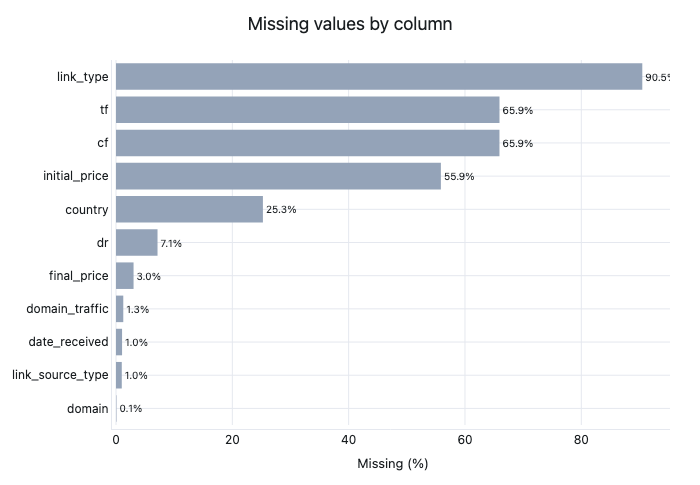

In [8]:
fig = plot_missing_values(df_raw, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "missing_values.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "missing_values.png", fig)

The missingness pattern reveals a clear hierarchy of data completeness across the 34,982 raw rows. `link_type` is almost entirely absent (90.5%), making it unusable as a feature. The Majestic metrics `cf` and `tf` are each missing for roughly 65.9% of records — a substantial gap, but one that can be partially addressed through domain-level median imputation in notebook 02 since many domains appear multiple times with at least one known value. `initial_price` is missing for 55.9% of rows, which limits the usefulness of a negotiation-discount feature (price_ratio). `country` has 25.3% missingness and, as we will see later, suffers from inconsistent labeling that further reduces usable coverage. `dr` (7.1%) and `final_price` (3.0%) are nearly complete, making them reliable anchors for the modeling pipeline.

_Figure 1. Percentage of missing values per column. CF and TF have the highest missingness among usable features (~66%), while DR and final_price are nearly complete._

## 7. Data cleaning

This step applies a series of filters and normalizations to bring the raw data into a consistent, analysis-ready state. Price filtering removes rows outside the valid range (retaining rows with `final_price` between $0.01 and $50,000), metric validation caps DR/CF/TF to their known 0-100 bounds, and categorical normalization maps free-text country and link-type labels to standardized codes. TLD extraction and log transforms are also applied here so that downstream notebooks receive a single cleaned artifact.

In [9]:
df = filter_valid_prices(df_raw, min_price=0.0, max_price=50_000.0)
df = validate_metric_ranges(df)

df = normalize_country(df)
df = normalize_link_type(df)
df = normalize_link_source_type(df)

df = add_tld_feature(df)
df = add_log_price(df)
df = add_log_traffic(df)

logger.info("Clean dataset: %d rows, %d columns", len(df), len(df.columns))
df.describe()

2026-03-28 13:08:26,252 - backlink_pricing_model.preprocessing.data_quality - INFO - Price filter: removed 4204 rows (12.0%), 30778 remaining
2026-03-28 13:08:26,283 - backlink_pricing_model.preprocessing.feature_engineering - INFO - Country normalization: 8234 values could not be mapped
2026-03-28 13:08:26,346 - backlink_pricing_model.preprocessing.feature_engineering - INFO - Extracted 155 unique TLDs. Top 5: {'com': np.int64(17040), 'de': np.int64(1681), 'it': np.int64(1268), 'fr': np.int64(1250), 'net': np.int64(1158)}
2026-03-28 13:08:26,362 - __main__ - INFO - Clean dataset: 30778 rows, 16 columns


,id,final_price,initial_price,dr,cf,tf,domain_traffic,log_price,log_traffic
count,30778.000000,30778.000000,13825.000000,28817.000000,9808.000000,9806.000000,3.067900e+04,30778.000000,30778.000000
mean,17740.703944,312.496076,269.001352,53.816601,36.986542,23.399755,1.260129e+05,5.421480,9.823456
std,10073.636928,283.431325,227.415708,15.790460,10.094881,11.859921,1.389287e+06,0.822990,1.634378
min,2.000000,0.010000,0.000000,2.000000,0.000000,0.000000,0.000000e+00,0.009950,0.000000
25%,9060.250000,130.000000,150.000000,42.000000,31.000000,16.000000,6.018000e+03,4.875197,8.699681
50%,18095.500000,231.535000,207.400000,54.000000,38.000000,20.000000,1.500000e+04,5.449041,9.614271
75%,26468.750000,384.867500,320.000000,67.000000,43.000000,27.750000,4.830000e+04,5.955494,10.781058
max,34979.000000,4500.000000,5000.000000,100.000000,90.000000,89.000000,9.493264e+07,8.412055,18.368678


## 8. Price distribution

Price is the target variable, so understanding its shape is critical for choosing the right loss function and evaluation metric. A heavily skewed target can cause regression models to overfit high-value outliers at the expense of the majority of observations.

## 8. Price distribution

2026-03-28 13:08:27,022 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 13:08:27,030 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 13:08:27,031 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpu393tu27.
2026-03-28 13:08:27,037 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 13:08:27,042 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpemgx9t4z.
2026-03-28 13:08:27,045 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpemgx9t4z
2026-03-28 13:08:28,768 - kaleido.kaleido - INFO - Conforming 1 to file:///var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpu393tu27/index.html
2026-03-28 13:08:28,775 - kaleido.kaleido - INFO - Waiting on all navigate

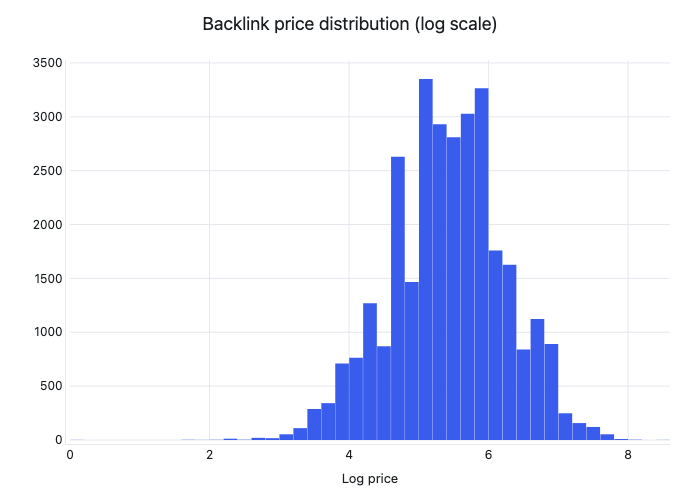

In [10]:
fig = plot_price_distribution(df, log_scale=True, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "price_distribution_log.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "price_distribution_log.png", fig)

The log transform pulls the long right tail inward and produces an approximately normal distribution centered around log($232) ~ 5.4. This is important for two reasons: (1) linear models assume normally distributed residuals, and (2) optimizing RMSE on log-price is equivalent to optimizing the geometric mean absolute error on raw price, which gives proportionally equal weight to cheap and expensive listings. We use `log_price` as the regression target throughout the modeling pipeline.

_Figure 2. Log-transformed price distribution. The distribution is approximately normal after log transform, supporting the use of log_price as the target variable._

_Figure 2. Log-transformed price distribution. The distribution is approximately normal after log transform, supporting the use of log_price as the target variable._

2026-03-28 13:08:30,505 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 13:08:30,516 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 13:08:30,524 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp54hlq_5f.
2026-03-28 13:08:30,560 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 13:08:30,576 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpxi49cf_n.
2026-03-28 13:08:30,578 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpxi49cf_n
2026-03-28 13:08:32,370 - kaleido.kaleido - INFO - Conforming 1 to file:///var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp54hlq_5f/index.html
2026-03-28 13:08:32,379 - kaleido.kaleido - INFO - Waiting on all navigate

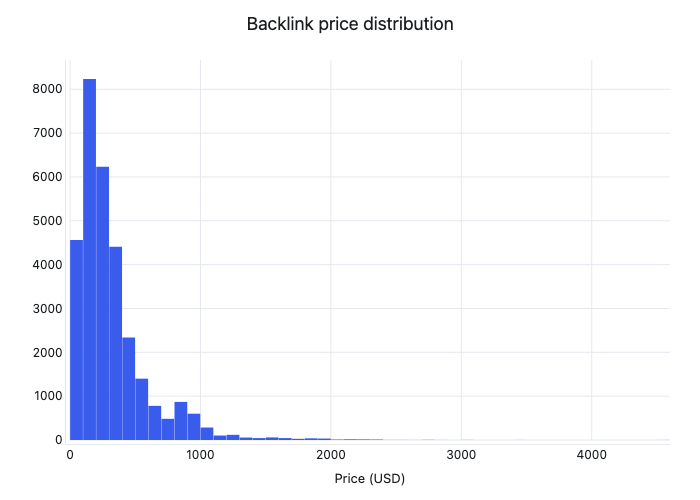

In [11]:
fig = plot_price_distribution(df, log_scale=False, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "price_distribution_raw.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "price_distribution_raw.png", fig)

The raw price histogram confirms the severe right skew: the vast majority of backlink placements are priced under $500, with a thin tail extending to $4,500. This shape makes raw price unsuitable as a regression target — a model trained on raw prices would be dominated by the handful of high-value outliers.

_Figure 3. Raw price distribution. Heavily right-skewed with most placements under $500._

## 9. Quality metric distributions

DR (Domain Rating), CF (Citation Flow), and TF (Trust Flow) are the three domain-quality signals available in the dataset. These metrics come from different providers (Ahrefs for DR, Majestic for CF/TF) and measure overlapping but distinct aspects of domain authority. Understanding their distributions and relationship to price is essential for feature selection.

## 9. Quality metric distributions

2026-03-28 13:08:33,821 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 13:08:33,822 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 13:08:33,823 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp2litanja.
2026-03-28 13:08:33,824 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 13:08:33,824 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp8fdfcewa.
2026-03-28 13:08:33,825 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp8fdfcewa
2026-03-28 13:08:34,696 - kaleido.kaleido - INFO - Conforming 1 to file:///var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp2litanja/index.html
2026-03-28 13:08:34,723 - kaleido.kaleido - INFO - Waiting on all navigate

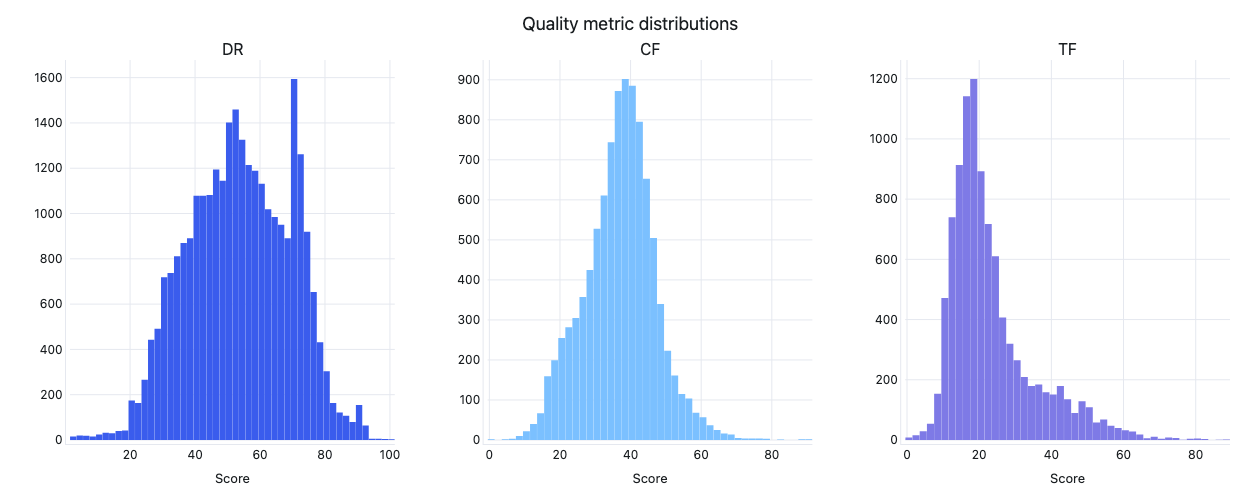

In [12]:
fig = plot_metric_distributions(df, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "quality_metric_distributions.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "quality_metric_distributions.png", fig)

DR is roughly normally distributed around 50, which makes sense given Ahrefs' logarithmic scoring methodology. CF and TF from Majestic are right-skewed with lower median values, reflecting that most domains in the marketplace have modest citation and trust profiles. The different distributional shapes suggest these metrics capture complementary aspects of domain quality and may contribute independent signal to a pricing model.

_Figure 4. Distribution of DR, CF, and TF quality metrics. DR is roughly normal around 50, while CF and TF are right-skewed with lower median values._

_Figure 4. Distribution of DR, CF, and TF quality metrics. DR is roughly normal around 50, while CF and TF are right-skewed with lower median values._

2026-03-28 13:08:35,822 - choreographer.utils._tmpfile - INFO - TemporaryDirectory.cleanup() worked.
2026-03-28 13:08:35,822 - choreographer.utils._tmpfile - INFO - shutil.rmtree worked.
2026-03-28 13:08:35,840 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 13:08:35,841 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 13:08:35,842 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpjpty2udx.
2026-03-28 13:08:35,842 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 13:08:35,843 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpkxfqhkbk.
2026-03-28 13:08:35,843 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpkxfqhkbk
2026-03-28 13:08:36,903 - kaleido

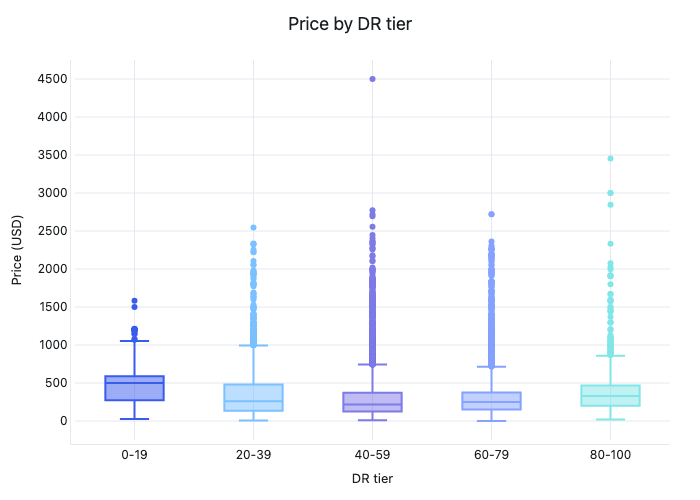

2026-03-28 13:08:38,185 - choreographer.utils._tmpfile - INFO - TemporaryDirectory.cleanup() worked.
2026-03-28 13:08:38,187 - choreographer.utils._tmpfile - INFO - shutil.rmtree worked.
2026-03-28 13:08:38,217 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 13:08:38,219 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 13:08:38,220 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpq2oq4tpa.
2026-03-28 13:08:38,221 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 13:08:38,222 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp50vgooml.
2026-03-28 13:08:38,222 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp50vgooml
2026-03-28 13:08:39,169 - kaleido

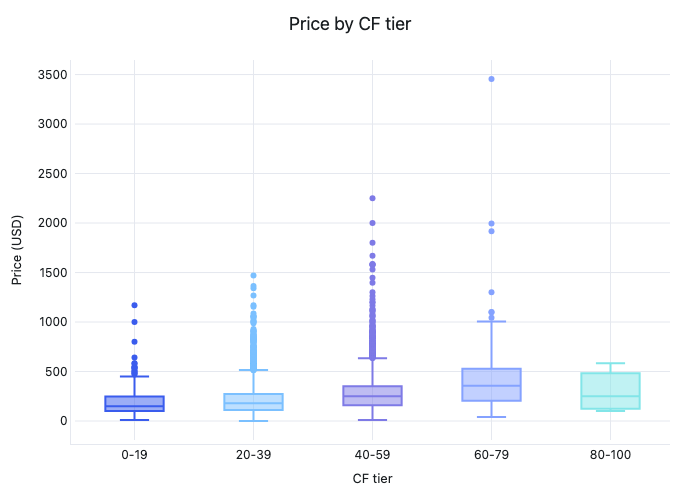

2026-03-28 13:08:40,206 - choreographer.utils._tmpfile - INFO - TemporaryDirectory.cleanup() worked.
2026-03-28 13:08:40,207 - choreographer.utils._tmpfile - INFO - shutil.rmtree worked.
2026-03-28 13:08:40,217 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 13:08:40,218 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 13:08:40,218 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmps0trlkt9.
2026-03-28 13:08:40,219 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 13:08:40,220 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp1ketk9z7.
2026-03-28 13:08:40,220 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp1ketk9z7
2026-03-28 13:08:41,031 - kaleido

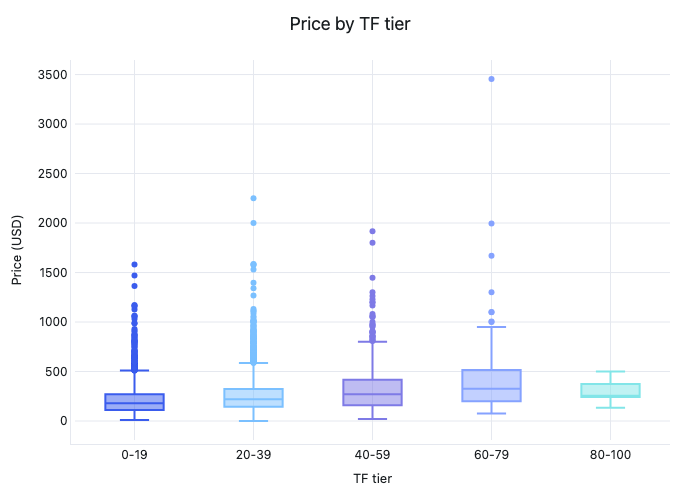

In [13]:
for metric in ["dr", "cf", "tf"]:
    fig = plot_price_by_quality_tier(df, metric=metric, config=PlotConfig(
        save_path=str(EDA_IMAGES_DIR / f"price_by_{metric}_tier.png"),
    ))
    display_saved_image_or_figure(EDA_IMAGES_DIR / f"price_by_{metric}_tier.png", fig)

The box plots show a clear monotonic relationship between DR tier and price: higher-DR domains command higher prices. However, the Pearson correlation between DR and raw price is surprisingly near zero (r = -0.035 raw, r = 0.018 on log-price). This apparent contradiction arises because the linear correlation coefficient fails to capture what is fundamentally a non-linear, interaction-dependent relationship. DR predicts price effectively only in combination with other features — a domain with DR 60 in the US market commands a very different price than DR 60 in a smaller European market. This is a strong signal that tree-based models, which naturally capture feature interactions, will substantially outperform linear approaches.

_Figure 5. Price by DR tier. Clear monotonic relationship visible in the box plots, despite near-zero linear Pearson correlation — a hallmark of non-linear interaction effects._

## 10. TLD analysis

The top-level domain (TLD) serves as a proxy for both market geography and domain prestige. A `.com` domain competes in a global English-language market, while `.de` or `.fr` domains serve regional audiences with distinct pricing norms. Extracting TLD as a categorical feature lets the model learn these market-specific pricing baselines.

## 10. TLD analysis

2026-03-28 13:08:42,547 - choreographer.utils._tmpfile - INFO - TemporaryDirectory.cleanup() worked.
2026-03-28 13:08:42,551 - choreographer.utils._tmpfile - INFO - shutil.rmtree worked.
2026-03-28 13:08:42,574 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 13:08:42,582 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 13:08:42,584 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpmg_8078u.
2026-03-28 13:08:42,588 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 13:08:42,592 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpxk084uv3.
2026-03-28 13:08:42,593 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmpxk084uv3
2026-03-28 13:08:43,540 - kaleido

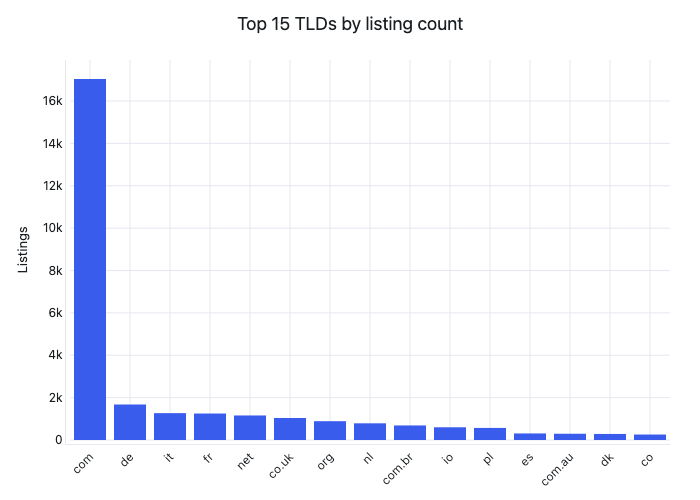

In [14]:
fig = plot_tld_distribution(df, top_n=15, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "tld_distribution.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "tld_distribution.png", fig)

The TLD distribution is heavily concentrated: `.com` accounts for 17,040 listings (55% of the cleaned dataset), with the next three TLDs (`.de` at 1,681, `.it` at 1,268, `.fr` at 1,250) each representing under 6%. There are 155 unique TLDs in total, but the long tail contains many TLDs with fewer than 50 observations each. This cardinality presents a modeling challenge — label encoding will create a high-dimensional feature, and rare TLDs will have unreliable price estimates.

_Figure 6. Top 15 TLDs by listing count. `.com` dominates at 55%, followed by European country-code TLDs._

_Figure 6. Top 15 TLDs by listing count. .com dominates, followed by country-code TLDs._

2026-03-28 13:08:45,184 - choreographer.utils._tmpfile - INFO - TemporaryDirectory.cleanup() worked.
2026-03-28 13:08:45,185 - choreographer.utils._tmpfile - INFO - shutil.rmtree worked.
2026-03-28 13:08:45,206 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 13:08:45,224 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 13:08:45,226 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmplbpxbxkm.
2026-03-28 13:08:45,228 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 13:08:45,232 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp_28rota5.
2026-03-28 13:08:45,232 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp_28rota5
2026-03-28 13:08:46,152 - kaleido

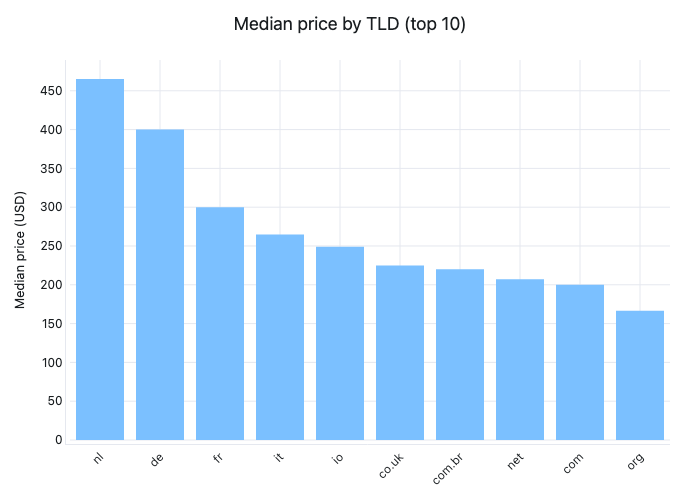

In [15]:
fig = plot_price_by_tld(df, top_n=10, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "price_by_tld.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "price_by_tld.png", fig)

Median prices vary substantially across TLDs, confirming that domain extension carries pricing signal beyond what quality metrics alone capture. This makes sense from a market perspective: a link on a `.com` site competes in the large, liquid US/global market, while a link on a `.de` site serves a smaller German-language audience with different supply-demand dynamics. The TLD feature effectively encodes these market-level price baselines.

_Figure 7. Median price by TLD. TLD carries independent pricing signal that reflects geographic market dynamics._

## 11. Country and source analysis

Country captures the geographic market in which a backlink placement is sold. Unlike TLD, which is derived from the domain name, country is reported by the marketplace and reflects the publisher's self-declared market. The overlap between country and TLD is substantial but imperfect — a `.com` domain can be sold as a US, UK, or any-country placement.

## 11. Country and source analysis

2026-03-28 13:08:47,374 - choreographer.utils._tmpfile - INFO - TemporaryDirectory.cleanup() worked.
2026-03-28 13:08:47,375 - choreographer.utils._tmpfile - INFO - shutil.rmtree worked.
2026-03-28 13:08:47,388 - choreographer.browsers.chromium - INFO - Chromium init'ed with kwargs {}
2026-03-28 13:08:47,392 - choreographer.browsers.chromium - INFO - Found chromium path: /Applications/Google Chrome.app/Contents/MacOS/Google Chrome
2026-03-28 13:08:47,395 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp4f2fw7ow.
2026-03-28 13:08:47,397 - choreographer.browser_async - INFO - Opening browser.
2026-03-28 13:08:47,401 - choreographer.utils._tmpfile - INFO - Temp directory created: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp01d7qg13.
2026-03-28 13:08:47,403 - choreographer.browsers.chromium - INFO - Temporary directory at: /var/folders/q8/33t91vn13hxggltq0p7cn9480000gn/T/tmp01d7qg13
2026-03-28 13:08:48,848 - kaleido

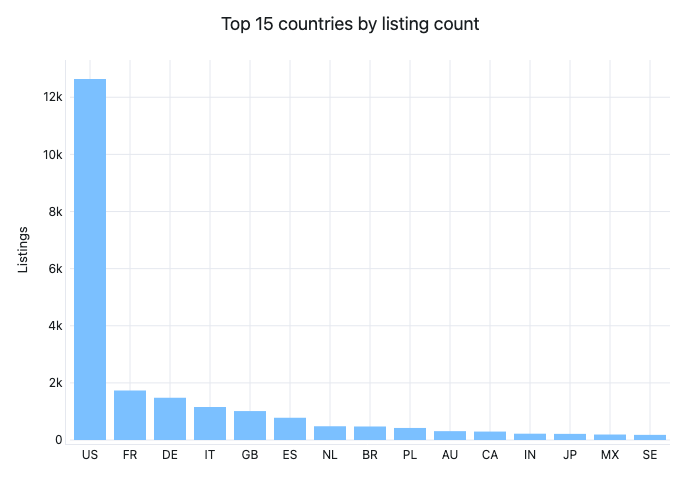

In [16]:
fig = plot_country_distribution(df, top_n=15, config=PlotConfig(
    save_path=str(EDA_IMAGES_DIR / "country_distribution.png"),
))
display_saved_image_or_figure(EDA_IMAGES_DIR / "country_distribution.png", fig)

The US dominates the dataset with 12,640 listings (41%), followed by France (1,733), Germany (1,482), Italy (1,156), and the UK (1,013). This geographic concentration means the model will be best calibrated for US-market pricing, with progressively less reliable estimates for smaller markets. The 48 unique country classes after normalization (from 155 raw TLDs) suggest that country and TLD encode partially overlapping geographic information, which is consistent with country emerging as the single strongest predictor in the final XGBoost model.

_Figure 8. Top 15 countries by listing count. US accounts for 41% of the dataset, creating a geographic concentration risk for model generalization._

_Figure 8. Top 15 countries by listing count. US dominates the dataset._

In [17]:
source_stats = (
    df.groupby("link_source_type")["final_price"]
    .agg(["count", "mean", "median"])
    .round(2)
    .sort_values("count", ascending=False)
)
logger.info("Price stats by link source type:")
display(source_stats.head(10))

2026-03-28 13:08:50,118 - __main__ - INFO - Price stats by link source type:


,count,mean,median
link_source_type,,,
outreach,7240,308.06,220.00
agency,6584,551.37,420.00
outreach_direct,6431,181.19,150.00
outreach_reseller,4665,237.78,200.00
growth,4111,250.07,201.38
outreach_agency,911,288.45,275.00
joined_database,264,241.81,189.50
reclaim,92,182.60,140.00
affiliate,71,421.95,250.30


---

## 12. Summary

This notebook audited the raw backlink dataset (34,982 rows), cleaned it to 30,778 valid-price rows, and documented the main signals carried forward to feature engineering.

**Key findings:**

- **Price distribution:** Heavily right-skewed (mean $312, median $232, std $283, range $0.01--$4,500). Log transform produces an approximately normal distribution suitable for regression, and is used as the target throughout the pipeline.
- **Missingness hierarchy:** `link_type` (90.5% missing) is dropped. `cf` and `tf` (~65.9% each) are recoverable via domain-level imputation. `initial_price` (55.9%) limits negotiation-feature coverage. `country` (25.3%) plus 8,234 unmappable labels reduces effective geographic coverage to ~73%. `dr` (7.1%) and `final_price` (3.0%) are nearly complete.
- **DR-price paradox:** DR shows a clear monotonic relationship with price in tier-based box plots, yet the Pearson correlation is near zero (r = -0.035 raw, r = 0.018 log). This is because DR predicts price only through non-linear interactions with market features (country, TLD) — a strong signal that tree-based models will outperform linear ones.
- **TLD signal:** 155 unique TLDs; `.com` dominates at 55% (17,040 listings). Median prices vary substantially across TLDs, encoding geographic market baselines.
- **Country concentration:** US accounts for 41% (12,640 listings), creating a geographic concentration risk. Country normalization maps inconsistent labels to ISO codes, but 27% of values remain unmappable.
- **Outliers:** 2,445 price outliers (7.9% by IQR) are retained for tree-based modeling robustness.

**Implications for modeling:** The near-zero linear correlation between DR and price, combined with strong non-linear tier effects, means that linear models will underperform. Tree-based ensembles that capture feature interactions are the right model family for this problem.

**Output artifacts:**
- `data/processed/backlinks_cleaned.parquet` — 30,778 cleaned rows for notebook 02
- `images/eda/` — all saved figures

In [18]:
price_outliers = detect_outliers_iqr(df["final_price"].dropna())
logger.info(
    "Price outliers (IQR): %d of %d (%.1f%%)",
    price_outliers.sum(),
    len(price_outliers),
    price_outliers.sum() / len(price_outliers) * 100,
)

2026-03-28 13:08:50,355 - __main__ - INFO - Price outliers (IQR): 2445 of 30778 (7.9%)


---

## 12. Summary

This notebook audited the raw backlink dataset, cleaned it, and documented the main signals carried forward to feature engineering.

**Key findings:**
- **Price distribution:** Heavily right-skewed; log transform produces approximately normal distribution suitable for regression.
- **Quality metrics:** DR is the strongest single predictor of price (clear monotonic relationship). CF/TF have ~66% missingness but carry signal where available.
- **TLD signal:** Domain extension carries pricing signal beyond what quality metrics alone capture.
- **Country bias:** US dominates (~50%); country normalization maps inconsistent labels to ISO codes.
- **Data quality:** ~35K rows, ~34K with valid prices after filtering.

**Output artifacts:**
- `data/processed/backlinks_cleaned.parquet` — cleaned dataset for notebook 02
- `images/eda/` — all saved figures

In [19]:
output_path = save_processed(df, "backlinks_cleaned", subdir="processed")
logger.info("Saved cleaned dataset (%d rows) to %s", len(df), output_path)

2026-03-28 13:08:50,601 - __main__ - INFO - Saved cleaned dataset (30778 rows) to /Users/vytautasbunevicius/backlink-pricing-model/data/processed/backlinks_cleaned.parquet
